In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [16]:
df = pd.read_csv("gpu_1986-2026.csv", usecols=["Brand", "Name", "Graphics Card__Release Date", "Memory__Memory Size"])
df.head()

,Brand,Name,Graphics Card__Release Date,Memory__Memory Size
0,ATI,Color Emulation Card,"Aug 4th, 1986",32 KB
1,ATI,Graphics Solution,"Sep 22nd, 1986",64 KB
2,ATI,EGA Wonder 800,"Nov 16th, 1987",256 KB
3,ATI,Graphics Solution Plus,"Mar 23rd, 1987",64 KB
4,ATI,VGA Improved Performance,"Sep 28th, 1987",256 KB


In [17]:
column_namechange = {
    "Graphics Card__Release Date": "Date",
    "Memory__Memory Size": "Memory"
}

for old, new in column_namechange.items():
    df[new] = df[old]
    df = df.drop(columns=[old])
df

,Brand,Name,Date,Memory
0,ATI,Color Emulation Card,"Aug 4th, 1986",32 KB
1,ATI,Graphics Solution,"Sep 22nd, 1986",64 KB
2,ATI,EGA Wonder 800,"Nov 16th, 1987",256 KB
3,ATI,Graphics Solution Plus,"Mar 23rd, 1987",64 KB
4,ATI,VGA Improved Performance,"Sep 28th, 1987",256 KB
...,...,...,...,...
3198,XGI,Volari V5 Ultra,"Sep 15th, 2003",256 MB
3199,XGI,Volari V8,"Sep 15th, 2003",256 MB
3200,XGI,Volari V8,"Sep 15th, 2003",256 MB
3201,XGI,Volari V8 Ultra,"Sep 15th, 2003",256 MB


In [18]:
df = df.dropna(subset=["Date"]).copy()

In [19]:
multipliers = {"GB": 1, "MB": 1/1024, "KB": 1/1024**2}

tmp = df["Memory"].str.extract(r"(?i)(\d+)\s*(GB|MB|KB)")

tmp[0] = tmp[0].astype(float)

tmp[1] = tmp[1].map(multipliers)

df["Memory_inGB"] = tmp[0] * tmp[1]


In [20]:
df

,Brand,Name,Date,Memory,Memory_inGB
0,ATI,Color Emulation Card,"Aug 4th, 1986",32 KB,0.000031
1,ATI,Graphics Solution,"Sep 22nd, 1986",64 KB,0.000061
2,ATI,EGA Wonder 800,"Nov 16th, 1987",256 KB,0.000244
3,ATI,Graphics Solution Plus,"Mar 23rd, 1987",64 KB,0.000061
4,ATI,VGA Improved Performance,"Sep 28th, 1987",256 KB,0.000244
...,...,...,...,...,...
3198,XGI,Volari V5 Ultra,"Sep 15th, 2003",256 MB,0.250000
3199,XGI,Volari V8,"Sep 15th, 2003",256 MB,0.250000
3200,XGI,Volari V8,"Sep 15th, 2003",256 MB,0.250000
3201,XGI,Volari V8 Ultra,"Sep 15th, 2003",256 MB,0.250000


In [21]:
# df["Date"] = df["Date"].str.replace(
#     r"(\d{1,2})(st|nd|rd|th)",
#     r"\1",                     
#     regex=True
# )
df["Date"] = pd.to_datetime(df["Date"], format="mixed")
df["Year"] = df["Date"].dt.year

df

,Brand,Name,Date,Memory,Memory_inGB,Year
0,ATI,Color Emulation Card,1986-08-04,32 KB,0.000031,1986
1,ATI,Graphics Solution,1986-09-22,64 KB,0.000061,1986
2,ATI,EGA Wonder 800,1987-11-16,256 KB,0.000244,1987
3,ATI,Graphics Solution Plus,1987-03-23,64 KB,0.000061,1987
4,ATI,VGA Improved Performance,1987-09-28,256 KB,0.000244,1987
...,...,...,...,...,...,...
3198,XGI,Volari V5 Ultra,2003-09-15,256 MB,0.250000,2003
3199,XGI,Volari V8,2003-09-15,256 MB,0.250000,2003
3200,XGI,Volari V8,2003-09-15,256 MB,0.250000,2003
3201,XGI,Volari V8 Ultra,2003-09-15,256 MB,0.250000,2003


In [31]:
df_avg_memory = df.groupby("Year", as_index=False)["Memory_inGB"].median()
df_avg_memory["Year"] = pd.to_datetime(df_avg_memory["Year"], format="%Y")

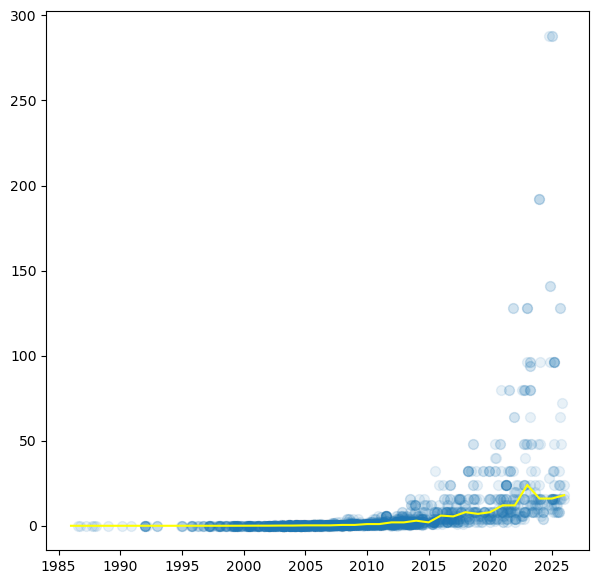

In [42]:
fig, ax = plt.subplots(figsize=(7,7))

x = df["Date"]
y = df["Memory_inGB"]

ax.scatter(x, y, s=50, alpha=.1)
ax.plot(
    df_avg_memory["Year"], 
    df_avg_memory["Memory_inGB"], 
    color="yellow", 
    label="Median"
    )



plt.show()